<a href="https://colab.research.google.com/github/layaltalali9/layallap/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 3: Image Enhancement in the Spatial Domain with Python**

## **Learning Objectives**
By the end of this practical, you should be able to:
* Explain the purpose of image enhancement and distinguish it from image restoration.
* Interpret image histograms and relate them to contrast and visual quality.
* Apply histogram equalisation and explain its effect on grey level distribution.
* Implement basic point processing transformations.
* Apply spatial filtering using neighbourhood operations.
* Compare smoothing and sharpening filters and explain their effects.
* Reason about edge effects and boundary handling in filtering.
* Combine multiple enhancement operations to achieve a desired outcome.

---

## **1. Introduction to Image Enhancement**
Image enhancement aims to improve the visual usefulness of an image by emphasising important features or suppressing unwanted effects such as noise.

**Typical goals include:**
* Improving contrast.
* Highlighting fine detail.
* Reducing noise.

This practical focuses on **spatial domain techniques**, where pixel values are manipulated directly.

---

## **2. Image Histograms and Contrast**
An image histogram describes the distribution of grey levels in an image and is a key tool for analysing contrast.

### **Exercise 2.1: Visualising an Image Histogram**
**Task:** Complete the code below to visualize the histogram of a randomly generated image.

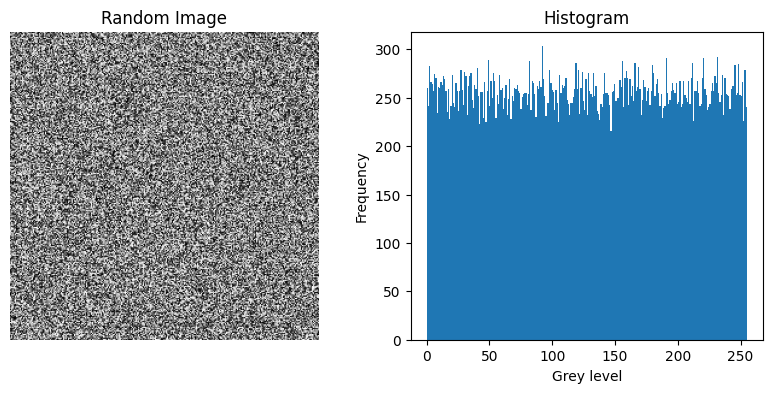

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a random image (256x256) with values between 0-255
# --- STUDENT TASK ---
# Fill in the parameters for np.randint()

image = np.random.randint(0, 256, (256, 256))

plt.figure(figsize=(10, 4))

# Display the image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Random Image")
plt.axis('off')

# 2. Plot the Histogram
plt.subplot(1, 2, 2)

# --- STUDENT TASK ---
# Fill in the parameters for plt.hist()
# Hint: You need to flatten the image, set bins to 256, and range to (0, 255)
plt.hist(image.flatten(), bins=256, range=(0,255))
plt.title("Histogram")
plt.xlabel("Grey level")
plt.ylabel("Frequency")
plt.show()

# --- DISCUSSION QUESTIONS ---
#1.	Is the histogram evenly distributed or clustered in certain ranges?
#1) The histogram is fairly evenly distributed because the image is random.

#2.	What does this suggest about the contrast of the image?
#2) This indicates good contrast since the intensity values cover most of the grey level range.

## **3. Normalised Histograms**
Histograms are often normalised so they can be interpreted as probability distributions. A normalised histogram shows the probability of occurrence of each grey level.

### **Exercise 3.1: Computing a Normalised Histogram**
**Task:** Complete the code to calculate the normalised histogram. Remember that the sum of a normalised histogram must equal 1.

In [14]:
# Calculate the basic histogram first
hist, bins = np.histogram(image.flatten(), bins=256, range=(0,255))
# --- STUDENT TASK ---
# Calculate the normalised histogram
# Hint: Divide the histogram (hist) by the total number of pixels in the image
hist_norm = hist / hist.sum()
print(hist_norm.sum())

# --- DISCUSSION QUESTIONS ---
# 1.	Why does the normalised histogram sum to 1?
#1) Because each value is divided by the total number of pixels, so the histogram represents probabilities. When all probabilities are added together, the total must equal 1.
# 2.	How can p(rₖ) be interpreted probabilistically?
#2) p(rₖ) represents the probability that a randomly selected pixel from the image has intensity level rₖ.


1.0


## **4. Histogram Equalisation**
Histogram equalisation is a technique used to improve contrast by redistributing the intensity levels. It spreads out the most frequent intensity values, resulting in a more uniform distribution.

### **Exercise 4.1: Manual Histogram Equalisation**
**Task:** Fill in the missing steps to implement the equalisation process using the Cumulative Distribution Function (CDF).

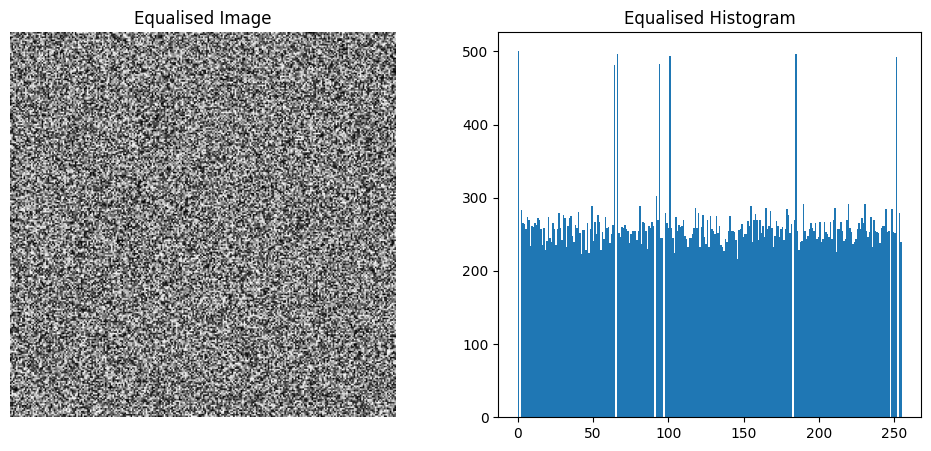

In [15]:
def hist_equalise(img):

    # Step 1: Calculate the histogram
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0,255))

    # Step 2: Calculate the Cumulative Distribution Function (CDF)
    # --- STUDENT TASK ---
    # Hint: Use the numpy function that calculates the cumulative sum (cumsum)
    cdf = np.cumsum(hist)

    # Step 3: Normalise the CDF to be in the range [0, 255]
    # Formula: (cdf - min) * 255 / (max - min)
    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_norm = cdf_norm.astype(np.uint8)

    # Step 4: Map the original image pixels to the new values
    return cdf_norm[img]


# Applying the function to the original random image
equalised_image = hist_equalise(image)


# Visual comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(equalised_image, cmap='gray', vmin=0, vmax=255)
plt.title("Equalised Image")
plt.axis('off')

plt.subplot(1, 2, 2)

# --- STUDENT TASK ---
# Plot the histogram of the equalised image to see the effect
plt.hist(equalised_image.flatten(), bins=256, range=(0,255))

plt.title("Equalised Histogram")

plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. How does the equalised histogram differ from the original one?
#1) The equalised histogram is more spread out across the grey levels compared to the original one. Instead of being concentrated in certain intensity ranges, it becomes more uniform.
# 2. Does histogram equalisation always improve an image?
#2) No, it does not always improve the image. In some cases, it can over-enhance contrast or amplify noise, especially if the original image already has good contrast.

#**5. Local histogram equalisation (conceptual)**
Instead of applying histogram equalisation globally, it can be applied locally to small regions.

## **Exercise 5.1: Conceptual analysis**

**Without writing code:**

• Explain why local histogram equalisation can enhance local detail

• Explain why it may also amplify noise


## **6. Point processing operations**
Point processing modifies each pixel independently using a transformation function:
s = T(r)

### **Exercise 6.1: Creating a Negative Image**
**Task:** Complete the code to calculate the negative of the input image.

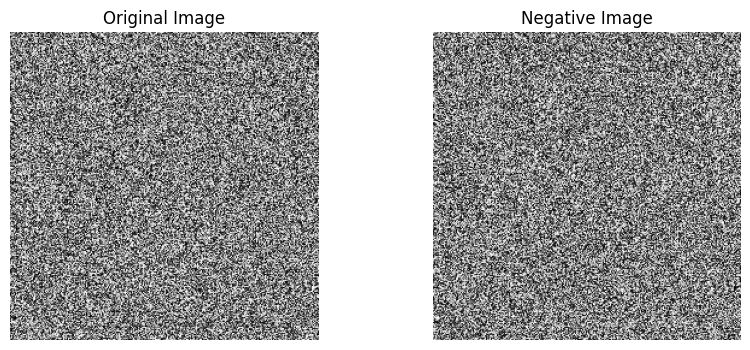

In [16]:
# --- STUDENT TASK ---
# Calculate the negative of the 'image' by subtracting each pixel from 255
negative_img = 255 - image

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_img, cmap='gray', vmin=0, vmax=255)
plt.title("Negative Image")
plt.axis('off')

plt.show()

# --- DISCUSSION QUESTIONS ---
# 1.	Why does this transformation highlight bright structures in dark regions?
#1) Because the transformation inverts intensity values. Dark pixels become bright and bright pixels become dark, which can make previously less visible structures stand out more clearly.

# 2.	In which types of images is this particularly useful?
#2) It is especially useful in medical images or images where important details appear in darker regions, such as X-rays or microscopy images.

## **7. Thresholding**
Thresholding is a simple way of segmenting an image into a binary foreground and background.

### **Exercise 7.1: Binary Thresholding**
**Task:** Turn all pixels above a specific 'threshold' to white (255) and all others to black (0).

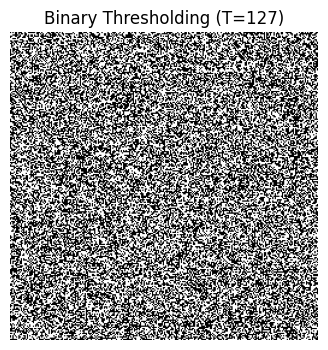

In [17]:
threshold = 127

# Create an image of zeros (black) with the same shape as the original
binary_img = np.zeros_like(image)

# --- STUDENT TASK ---
# Apply the threshold logic: set pixels to 255 where the original image > threshold_value
binary_img[image > threshold] = 255

plt.figure(figsize=(6, 4))
plt.imshow(binary_img, cmap='gray')
plt.title(f"Binary Thresholding (T={threshold})")
plt.axis('off')
plt.show()

# --- DISCUSSION QUESTIONS ---
#1.	What information is lost through thresholding?
#1)All grey-level details are lost. The image is reduced to only two values (0 and 255), so intensity variations within objects are removed.

#2.	Why is threshold selection critical?
#2) Because the threshold determines which pixels belong to the foreground and which belong to the background. A poor choice can remove important details or include unwanted noise.


## **8. Log Transformation and Gamma Correction**

### **Exercise 8.1: Log Transformation**
The log transformation maps a narrow range of low grey-level values into a wider range of output levels.
**Formula:** $s = c \log(1 + r)$

### **Exercise 8.2: Gamma Correction (Power-Law)**
Gamma correction is used to correct the non-linear response of display devices.
**Formula:** $s = c \cdot r^\gamma$

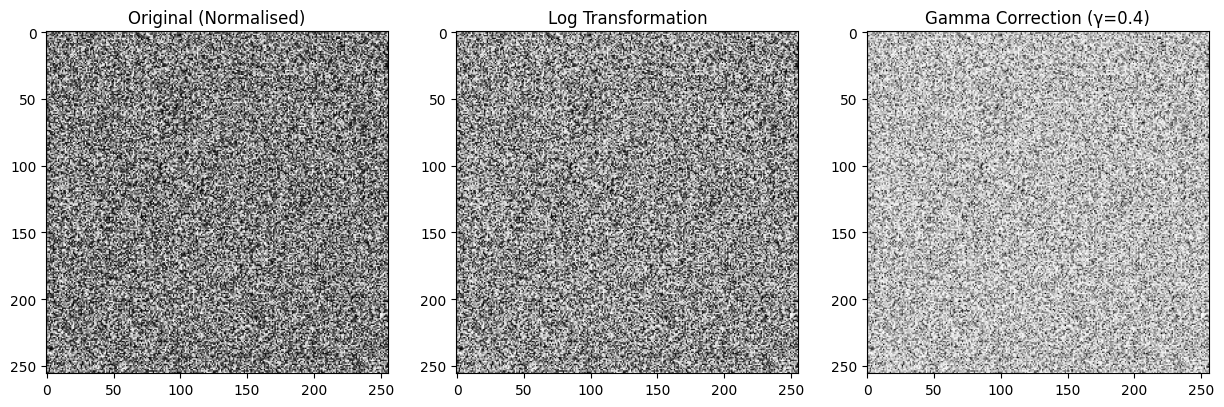

In [18]:
# First, normalise the image to the range [0, 1] for these calculations
image_norm = image / 255.0


# --- Exercise 8.1: Log Transformation ---
# --- STUDENT TASK ---
# Implement the log transformation: log(1 + image_norm)
log_img = np.log(1 + image_norm)


# --- Exercise 8.2: Gamma Correction ---
# --- STUDENT TASK ---
# Implement gamma correction with gamma = 0.4 (Brightening)
gamma = 0.4
gamma_img = image_norm ** gamma


# Visualisation
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_norm, cmap='gray')
plt.title("Original (Normalised)")

plt.subplot(1, 3, 2)
plt.imshow(log_img, cmap='gray')
plt.title("Log Transformation")

plt.subplot(1, 3, 3)
plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma Correction (γ={gamma})")

plt.show()

# --- DISCUSSION QUESTIONS (From the Lab Sheet) ---
# 1. Which range of intensity values (dark or light) are expanded in a log transformation?
#1) The log transformation expands low intensity (dark) values more than high intensity values.

# 2. Why is the log transformation useful for images with a very large dynamic range (e.g., Fourier spectra)?
#2) It compresses high intensity values while enhancing low intensity ones, making details in darker regions more visible.

# 3. How does decreasing gamma (e.g., to 0.4) affect the dark regions of an image?
#3) Decreasing gamma brightens the dark regions and increases their visibility.


# 4. Why is gamma correction important for display monitors?
#4) Display monitors have a non-linear response to brightness, so gamma correction compensates for this to ensure images appear visually correct.

## **9. Spatial Filtering: Smoothing**

### **Exercise 9.1: Mean (Averaging) Filter**
The Mean filter replaces each pixel value with the average of the pixels in its neighbourhood.

### **Exercise 9.2: Median Filter**
The Median filter replaces each pixel value with the median of the pixels in its neighbourhood.

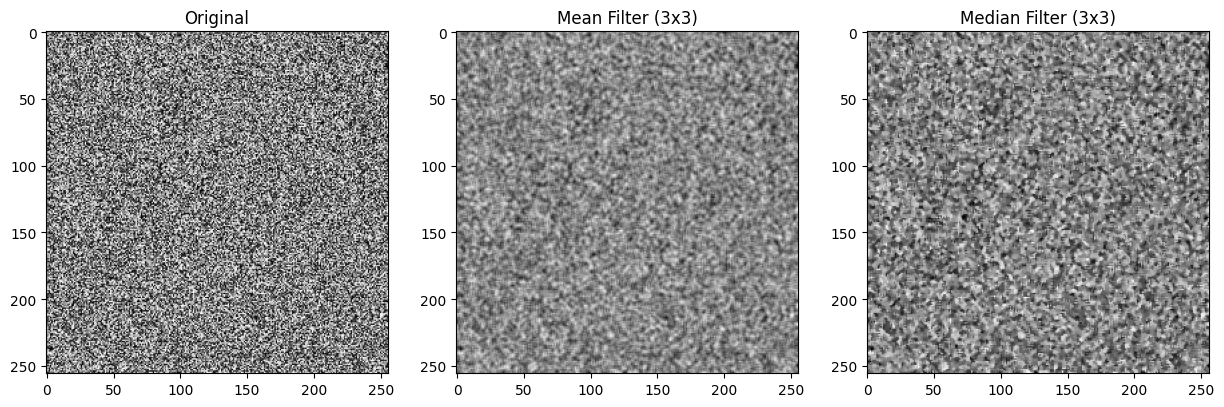

In [19]:
from scipy.ndimage import uniform_filter, median_filter

# --- Exercise 9.1: Mean Filter ---
# --- STUDENT TASK ---
# Apply a 3x3 mean filter using uniform_filter
mean_smoothed = uniform_filter(image, size=3)

# --- Exercise 9.2: Median Filter ---
# --- STUDENT TASK ---
# Apply a 3x3 median filter
median_smoothed = median_filter(image, size=3)

# Visualisation
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(mean_smoothed, cmap='gray'); plt.title("Mean Filter (3x3)")
plt.subplot(1, 3, 3); plt.imshow(median_smoothed, cmap='gray'); plt.title("Median Filter (3x3)")
plt.show()

# --- DISCUSSION QUESTIONS  ---
# 1.	What happens to noise and fine detail?
#1) Noise is reduced, but fine details and edges may become blurred, especially with the mean filter.

# 2.  How does filter size affect the result?
#2) A larger filter size increases smoothing, reduces more noise, but also removes more detail.


# 3.	Why does the median filter preserve edges better?
#3) Because it uses the median instead of the average, so extreme values (like noise) do not influence the result as much.

# 4.	What type of noise is it especially good at removing?
#4) It is particularly effective at removing salt-and-pepper noise.


## **10. Spatial Filtering: Sharpening**

### **Exercise 10.1: Laplacian Filter**
The Laplacian is a derivative operator that highlights regions of rapid intensity change. To sharpen an image, we subtract the Laplacian from the original image.

### **Exercise 10.2: Sobel Operator (Edge Detection)**
The Sobel operator calculates the image gradient, which is used to emphasize horizontal and vertical edges.

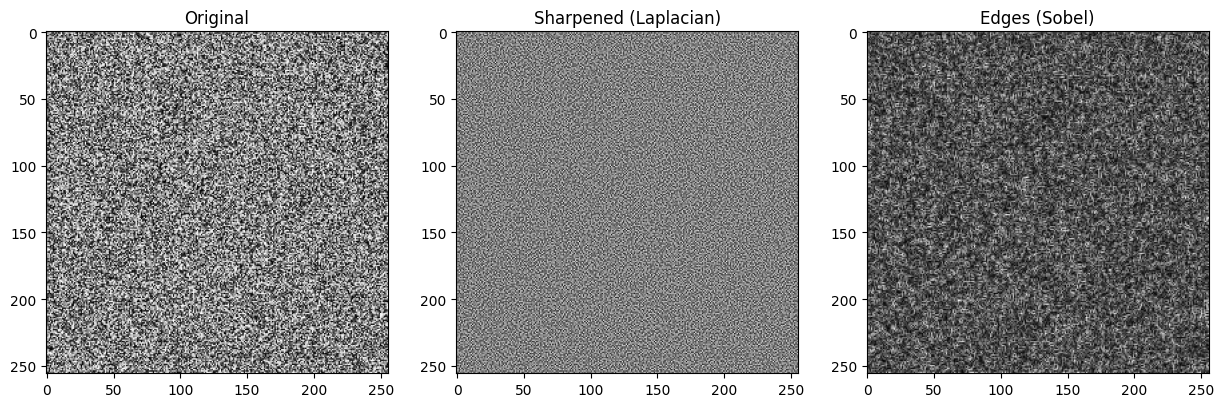

In [20]:
from scipy.ndimage import laplace, sobel

# --- Exercise 10.1: Laplacian Sharpening ---

# 1. Calculate the Laplacian
# --- STUDENT TASK ---
lap = laplace(image)

# 2. Subtract Laplacian from the original image to sharpen it
sharpened = image - lap


# --- Exercise 10.2: Sobel Edge Detection ---
# --- STUDENT TASK ---

# 1. Calculate horizontal gradient (axis=0)
sx = sobel(image, axis=0)

# 2. Calculate vertical gradient (axis=1)
sy = sobel(image, axis=1)

# Calculate the magnitude of the edges
edges = np.hypot(sx, sy)


# Visualisation
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(sharpened, cmap='gray'); plt.title("Sharpened (Laplacian)")
plt.subplot(1, 3, 3); plt.imshow(edges, cmap='gray'); plt.title("Edges (Sobel)")
plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. Why does subtracting the Laplacian from the original image lead to sharpening?
#1) The Laplacian highlights areas of rapid intensity change (edges). Subtracting it enhances these high-frequency components, making edges appear sharper.

# 2. What kind of structures are highlighted by the Laplacian?
#2) Edges, fine details, and regions with strong intensity variations.

# 3. What do the Sobel operators measure?
#3) They measure the image gradient, which represents the rate of change of intensity in horizontal and vertical directions.

# 4. Why are horizontal and vertical filters combined in edge detection?
#4) Because edges can appear in any direction. Combining both gradients gives the overall edge magnitude regardless of orientation.


## **11. Edge Effects and Boundary Handling**
When filtering, the mask (kernel) overlaps the edge of the image. We must decide how to handle these boundary pixels.

### **Exercise 11.1: Comparing Boundary Modes**
**Task:** Observe how different 'modes' in `uniform_filter` affect the borders of the image.

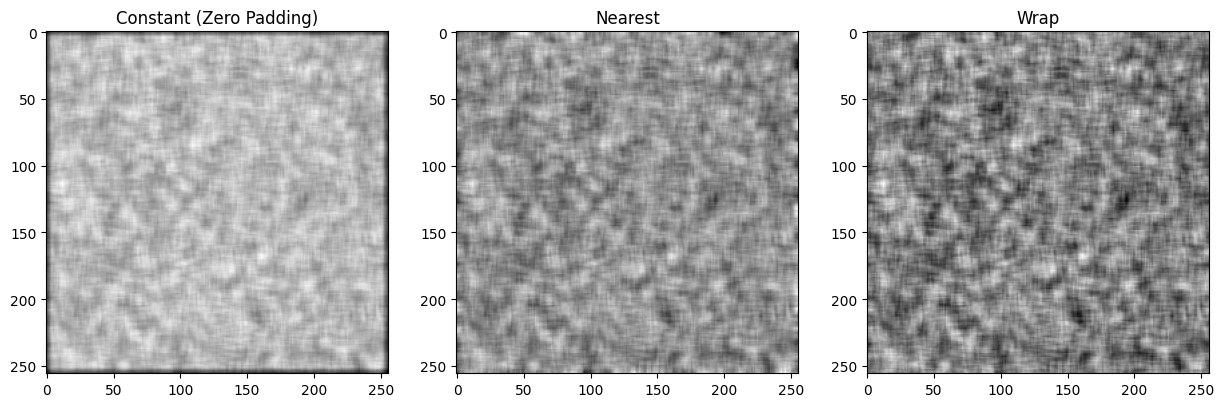

In [21]:
from scipy.ndimage import uniform_filter

# --- STUDENT TASK ---
# Try different modes: 'constant' (zero padding), 'nearest', 'wrap'
smoothed_const = uniform_filter(image, size=9, mode='constant', cval=0)
smoothed_near = uniform_filter(image, size=9, mode='nearest')
smoothed_wrap = uniform_filter(image, size=9, mode='wrap')

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(smoothed_const, cmap='gray')
plt.title("Constant (Zero Padding)")

plt.subplot(1,3,2)
plt.imshow(smoothed_near, cmap='gray')
plt.title("Nearest")

plt.subplot(1,3,3)
plt.imshow(smoothed_wrap, cmap='gray')
plt.title("Wrap")

plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. How does 'zero padding' affect the appearance of the image boundaries?
#1) Zero padding introduces artificial dark borders because the filter includes zero values outside the image, which reduces the intensity near the edges.

# 2. In what situations might 'wrap around' be a suitable boundary handling strategy?
#2) Wrap around is suitable for periodic or repeating images, such as textures or frequency-domain representations.

# 3. Which strategy seems most 'natural' for general photographic images?
#3) The “nearest” mode usually appears more natural because it extends edge values without introducing artificial borders

## 12. Mini Project: Combining Techniques
**Task:** Your goal is to produce the best possible version of the original image by combining the techniques you've learned.

1.	Start with a grey scale image
2.	Apply histogram equalisation
3.	Apply a smoothing filter
4.	Apply a sharpening filter
5.	Compare the original and final images

**Your explanation must reference:**
• Histogram processing

• Smoothing

• Sharpening

• The trade off between noise reduction and detail preservation


## **Reflection questions**
1.	Why does histogram equalisation sometimes over enhance images?
2.	Why is no single enhancement method sufficient in practice?
3.	How does human perception influence what we consider a “good” enhancement?


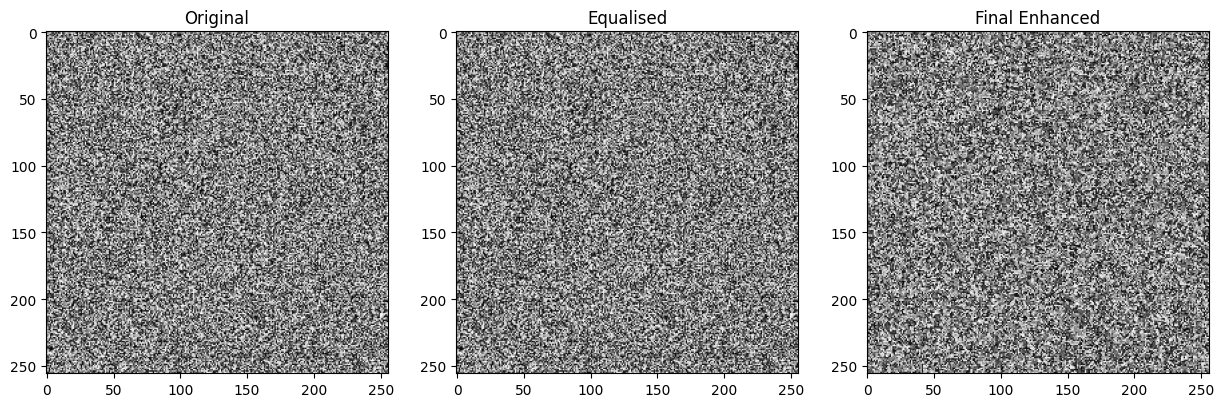

In [22]:
# Step 1: Start with grayscale image (already 'image')

# Step 2: Histogram Equalisation
eq = hist_equalise(image)

# Step 3: Apply smoothing filter
smooth = median_filter(eq, size=3)

# Step 4: Apply sharpening filter
lap = laplace(smooth)
final = smooth - lap

# Step 5: Compare
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(eq, cmap='gray')
plt.title("Equalised")

plt.subplot(1,3,3)
plt.imshow(final, cmap='gray')
plt.title("Final Enhanced")

plt.show()

Explanation


Histogram equalisation was first applied to improve contrast by spreading the intensity values across a wider range.

A smoothing filter was then used to reduce noise, since contrast enhancement can sometimes make noise more visible.

Finally, a sharpening filter (Laplacian) was applied to enhance edges and restore details lost during smoothing.

This process shows the trade-off between noise reduction and detail preservation. Smoothing reduces noise but can blur edges, while sharpening improves clarity but may amplify noise.

Reflection Questions

1. Why does histogram equalisation sometimes over-enhance images?
It can stretch intensity values too much and amplify noise, leading to unnatural contrast.

2. Why is no single enhancement method sufficient in practice?
Because each method improves one aspect but may negatively affect another.

3. How does human perception influence what we consider a “good” enhancement?
An image is considered good if it looks clear and natural to the human eye, not just mathematically improved.